# 36 — ICWSM & JCDL: Junior vs Senior Author Profiles

Pipeline:
1. Load `icwsm_jcdl_awards_raw.csv` and keep the 110 matched papers
2. Fetch full authorship lists from OpenAlex `/works/{id}`
3. For each unique author, fetch `/authors/{id}` → compute career age
4. Label junior (`career_age < 5`) vs senior
5. Save `icwsm_jcdl_author_profiles.csv` and do basic EDA


In [1]:
import pandas as pd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OPENALEX_EMAIL = 'sherotowshaw@gmail.com'  # replace with your email → polite pool
HEADERS = {'User-Agent': f'thesis-research mailto:{OPENALEX_EMAIL}'}
BASE = 'https://api.openalex.org'
SLEEP = 0.12  # ~8 req/s — safely within free-tier 10 req/s limit

def oa_get(url, params=None):
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    time.sleep(SLEEP)
    return r.json()


## 1. Load matched papers


In [2]:
df = pd.read_csv('../data/raw/icwsm_jcdl_awards_raw.csv')
df['matched'] = df['openalex_id'].notna() & (df['openalex_id'].str.strip() != '')

matched = df[df['matched']].copy().reset_index(drop=True)
print(f'Total rows       : {len(df)}')
print(f'Matched to OA    : {len(matched)}')
print(f'Unmatched (skip) : {len(df) - len(matched)}')
print()
matched.groupby(['conference', 'award_type']).size().reset_index(name='n')


Total rows       : 112
Matched to OA    : 110
Unmatched (skip) : 2



,conference,award_type,n
0,ICWSM,Best Paper,31
1,ICWSM,Test of Time,5
2,JCDL,Best Demonstration,1
3,JCDL,Best International Paper,2
4,JCDL,Best Poster,17
5,JCDL,Best Resource Paper,1
6,JCDL,Best Short Paper,3
7,JCDL,Best Student Paper,22
8,JCDL,Vannevar Bush Best Paper,28


## 2. Fetch authorships from OpenAlex `/works/{id}`


In [3]:
records = []

for _, row in matched.iterrows():
    work_id = str(row['openalex_id']).strip()
    try:
        data = oa_get(f'{BASE}/works/{work_id}')
    except Exception as e:
        print(f'  ERROR {work_id}: {e}')
        continue

    for a in data.get('authorships', []):
        author = a.get('author', {})
        records.append({
            'openalex_paper_id': work_id,
            'paper_title'      : row['paper_title'],
            'conference'       : row['conference'],
            'award_type'       : row['award_type'],
            'award_year'       : int(row['award_year']),
            'author_id'        : author.get('id', ''),
            'author_name'      : author.get('display_name', ''),
            'author_position'  : a.get('author_position', ''),  # first / middle / last
        })

authors_df = pd.DataFrame(records)
print(f'Author-paper rows : {len(authors_df)}')
print(f'Unique authors    : {authors_df["author_id"].nunique()}')
authors_df.head()


Author-paper rows : 398
Unique authors    : 327


,openalex_paper_id,paper_title,conference,award_type,award_year,author_id,author_name,author_position
0,https://openalex.org/W2122743328,TagAssist: Automatic Tag Suggestion for Blog P...,ICWSM,Best Paper,2007,https://openalex.org/A5060435130,Sanjay Sood,first
1,https://openalex.org/W2122743328,TagAssist: Automatic Tag Suggestion for Blog P...,ICWSM,Best Paper,2007,https://openalex.org/A5046276215,Sara Owsley,middle
2,https://openalex.org/W2122743328,TagAssist: Automatic Tag Suggestion for Blog P...,ICWSM,Best Paper,2007,https://openalex.org/A5114000097,Kristian J. Hammond,middle
3,https://openalex.org/W2122743328,TagAssist: Automatic Tag Suggestion for Blog P...,ICWSM,Best Paper,2007,https://openalex.org/A5109397252,Larry Birnbaum,last
4,https://openalex.org/W109801324,Wikipedian Self-Governance in Action: Motivati...,ICWSM,Best Paper,2008,https://openalex.org/A5064061802,Ivan Beschastnikh,first


## 3. Fetch author profiles → career age

Career age = `award_year − first_publication_year`  
First pub year = earliest year with `works_count > 0` in `counts_by_year`.  
Authors where this is unavailable are flagged as `career_age_missing=True` and excluded from junior/senior labelling.


In [4]:
unique_authors = authors_df[['author_id', 'author_name']].drop_duplicates('author_id')
print(f'Fetching {len(unique_authors)} unique author profiles...')

profile_rows = []
for _, row in unique_authors.iterrows():
    aid = str(row['author_id'])
    if not aid or not aid.startswith('https://openalex.org/'):
        profile_rows.append({'author_id': aid, 'first_pub_year': None,
                             'total_works': None, 'total_cites': None})
        continue
    try:
        data = oa_get(f"{BASE}/authors/{aid.split('/')[-1]}")
    except Exception as e:
        print(f'  ERROR {aid}: {e}')
        profile_rows.append({'author_id': aid, 'first_pub_year': None,
                             'total_works': None, 'total_cites': None})
        continue

    cby = data.get('counts_by_year', [])
    years_with_works = [c['year'] for c in cby if c.get('works_count', 0) > 0]
    first_year = min(years_with_works) if years_with_works else None

    profile_rows.append({
        'author_id'     : aid,
        'first_pub_year': first_year,
        'total_works'   : data.get('works_count'),
        'total_cites'   : data.get('cited_by_count'),
    })

profiles = pd.DataFrame(profile_rows)
print(f'Profiles fetched       : {len(profiles)}')
print(f'Missing first_pub_year : {profiles["first_pub_year"].isna().sum()}')


Fetching 328 unique author profiles...
Profiles fetched       : 328
Missing first_pub_year : 1


## 4. Merge & compute career age / junior label


In [5]:
full = authors_df.merge(profiles, on='author_id', how='left')

full['first_pub_year']    = pd.to_numeric(full['first_pub_year'], errors='coerce')
full['career_age']        = full['award_year'] - full['first_pub_year']
full['career_age_missing'] = full['career_age'].isna()

# junior = career_age < 5  (same threshold as existing notebooks 05-07)
full['is_junior'] = full['career_age'] < 5

print(full[['author_name', 'conference', 'award_year', 'first_pub_year',
            'career_age', 'is_junior']].head(10).to_string(index=False))


        author_name conference  award_year  first_pub_year  career_age  is_junior
        Sanjay Sood      ICWSM        2007          1995.0        12.0      False
        Sara Owsley      ICWSM        2007          2004.0         3.0       True
Kristian J. Hammond      ICWSM        2007          1963.0        44.0      False
     Larry Birnbaum      ICWSM        2007          1991.0        16.0      False
  Ivan Beschastnikh      ICWSM        2008          2006.0         2.0       True
    Travis Kriplean      ICWSM        2008          2007.0         1.0       True
  David W. McDonald      ICWSM        2008          1952.0        56.0      False
           Eric Sun      ICWSM        2009          2009.0         0.0       True
      Itamar Rosenn      ICWSM        2009          2009.0         0.0       True
     Cameron Marlow      ICWSM        2009          1998.0        11.0      False


## 5. Save output


In [6]:
out_path = '../data/raw/icwsm_jcdl_author_profiles.csv'
full.to_csv(out_path, index=False)
print(f'Saved  → {out_path}')
print(f'Shape  : {full.shape}')
full.dtypes


Saved  → ../data/raw/icwsm_jcdl_author_profiles.csv
Shape  : (398, 14)


openalex_paper_id      object
paper_title            object
conference             object
award_type             object
award_year              int64
author_id              object
author_name            object
author_position        object
first_pub_year        float64
total_works           float64
total_cites           float64
career_age            float64
career_age_missing       bool
is_junior                bool
dtype: object

## 6. EDA


In [7]:
eda = full[~full['career_age_missing']].copy()

print('=== Career-age coverage ===')
print(f'Authors with career age  : {len(eda)}')
print(f'Authors without (skipped): {full["career_age_missing"].sum()}')
print()

print('=== Junior / Senior share (all authors) ===')
print(eda['is_junior'].value_counts(normalize=True)
         .rename({True: 'Junior', False: 'Senior'})
         .map('{:.1%}'.format))
print()

print('=== Junior share by conference ===')
print(eda.groupby('conference')['is_junior']
         .agg(junior_share=lambda x: x.mean(), n='count')
         .assign(junior_share=lambda d: d['junior_share'].map('{:.1%}'.format)))
print()

print('=== Junior share by award type ===')
print(eda.groupby(['conference', 'award_type'])['is_junior']
         .agg(junior_share=lambda x: x.mean(), n='count')
         .assign(junior_share=lambda d: d['junior_share'].map('{:.1%}'.format)))


=== Career-age coverage ===
Authors with career age  : 389
Authors without (skipped): 9

=== Junior / Senior share (all authors) ===
is_junior
Senior    76.1%
Junior    23.9%
Name: proportion, dtype: object

=== Junior share by conference ===
           junior_share    n
conference                  
ICWSM             19.3%  140
JCDL              26.5%  249

=== Junior share by award type ===
                                    junior_share    n
conference award_type                                
ICWSM      Best Paper                      22.3%  121
           Test of Time                     0.0%   19
JCDL       Best Demonstration               0.0%    3
           Best International Paper         0.0%    6
           Best Poster                     32.1%   56
           Best Resource Paper             75.0%    4
           Best Short Paper                29.4%   17
           Best Student Paper              30.3%   76
           Vannevar Bush Best Paper        19.5%   87


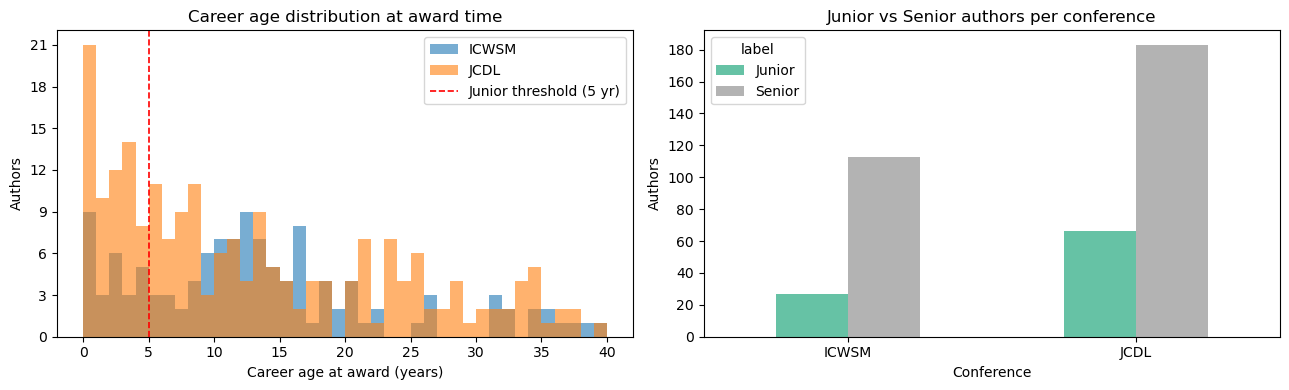

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: career age distribution by conference
for conf, grp in eda.groupby('conference'):
    axes[0].hist(grp['career_age'], bins=range(0, 41), alpha=0.6, label=conf)
axes[0].axvline(5, color='red', linestyle='--', linewidth=1.2, label='Junior threshold (5 yr)')
axes[0].set_xlabel('Career age at award (years)')
axes[0].set_ylabel('Authors')
axes[0].set_title('Career age distribution at award time')
axes[0].legend()
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# right: junior vs senior count by conference
share = (eda.groupby(['conference', 'is_junior'])
            .size()
            .reset_index(name='count')
            .assign(label=lambda d: d['is_junior'].map({True: 'Junior', False: 'Senior'})))
pivoted = share.pivot(index='conference', columns='label', values='count').fillna(0)
pivoted.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.5)
axes[1].set_xlabel('Conference')
axes[1].set_ylabel('Authors')
axes[1].set_title('Junior vs Senior authors per conference')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('../data/raw/eda_icwsm_jcdl_junior_senior.png', dpi=150)
plt.show()


In [9]:
# Median total works & citations: junior vs senior
comp = (eda.groupby('is_junior')[['total_works', 'total_cites']]
           .median()
           .rename(index={True: 'Junior (<5 yr)', False: 'Senior (>=5 yr)'})
           .round(1))
comp.columns = ['Median total works', 'Median total citations']
print(comp.to_string())


                 Median total works  Median total citations
is_junior                                                  
Senior (>=5 yr)               155.5                  3573.5
Junior (<5 yr)                 16.0                   270.0


In [10]:
# First authors only (most likely to be the main contributor)
first_authors = eda[eda['author_position'] == 'first'].copy()
print(f'First-author rows  : {len(first_authors)}')
print(f'Junior (first auth): {first_authors["is_junior"].sum()} '
      f'({first_authors["is_junior"].mean():.1%})')
print()
print('Junior share by conference (first authors only):')
print(first_authors.groupby('conference')['is_junior']
         .agg(junior_share=lambda x: x.mean(), n='count')
         .assign(junior_share=lambda d: d['junior_share'].map('{:.1%}'.format)))


First-author rows  : 108
Junior (first auth): 32 (29.6%)

Junior share by conference (first authors only):
           junior_share   n
conference                 
ICWSM             30.6%  36
JCDL              29.2%  72
